### Section: Synthetic Data Experiments and Ablation Study

This notebook conducts experiments using synthetically generated high-order streaming tensors. The primary objectives are:
1. **Scalability Analysis:** To evaluate the computational execution time and mathematical accuracy of the algorithms on high-dimensional data (e.g., $N=6$).
2. **Ablation Study:** To empirically demonstrate that the strict orthogonal gauge constraint in our proposed method is essential for preventing error accumulation and numerical instability compared to an unconstrained naive ALS update.
3. **Baseline Comparison:** To benchmark against TT-FOA, Full Batch TT-ALS, Slice-by-Slice Batch TT-ALS, and Mini-batch TT-ALS.

In [ ]:
# ---------------------------------------------------------
# Environment Setup and Initialization
# ---------------------------------------------------------
using LinearAlgebra
using Random
using TensorToolbox
using Plots
using Images
using ImageIO
using FileIO
using FFMPEG_jll
using Printf
using Statistics
using Revise
using JLD2

# Explicitly restrict BLAS to a single thread.
# This ensures a strictly fair evaluation of the computational execution time.
BLAS.set_num_threads(1)

In [2]:
includet("../julia_source/myGenerateData.jl")
includet("../julia_source/myLoadVideo.jl")
includet("../julia_source/myTTD.jl")

In [ ]:
# ---------------------------------------------------------
# Proposed Method: Online TT-ALS (State & Functions)
# ---------------------------------------------------------

"""
State container for the Online TT-ALS algorithm.
Pre-allocating buffers avoids memory reallocation overhead during streaming updates, 
which is critical for low-latency processing.
"""

mutable struct online_ttALSState
    M::Int # Number of spatial modes (equivalent to N-1)
    slice_sizes::Vector{Int}
    r::Vector{Int}
    G::Vector{Array{Float64, 3}}
    g_n::Vector{Float64}
    B_list_buffers::Vector{Matrix{Float64}}
    A_buffers::Vector{Matrix{Float64}}
end

function init_online_ttALS_state(slice_sizes::Vector{Int}, ttranks::Vector{Int})
    M = length(slice_sizes)
    r = [1; ttranks; 1]

    # Initialize spatial TT cores with random orthogonal values
    G = Vector{Array{Float64, 3}}(undef, M)
    for n in 1:M
        G[n] = randn(r[n], slice_sizes[n], r[n+1])
        G[n] /= norm(G[n])
    end

    g_n = randn(r[M+1])
    g_n /= norm(g_n)

    # Pre-allocate buffers for the right contraction matrices (B)
    B_list_buffers = Vector{Matrix{Float64}}(undef, M)
    B_list_buffers[M] = Matrix{Float64}(undef, r[M+1], 1)
    curr_right_dim = 1
    for k in (M-1):-1:1
        curr_right_dim *= slice_sizes[k+1]
        B_list_buffers[k] = Matrix{Float64}(undef, r[k+1], curr_right_dim)
    end

    # Pre-allocate buffers for the left contraction matrices (A)
    A_buffers = Vector{Matrix{Float64}}(undef, M+1)
    A_buffers[1] = Matrix{Float64}(undef, 1, 1)
    curr_left_dim = 1
    for k in 1:M
        curr_left_dim *= slice_sizes[k]
        A_buffers[k+1] = Matrix{Float64}(undef, curr_left_dim, r[k+1])
    end

    return online_ttALSState(M, slice_sizes, r, G, g_n, B_list_buffers, A_buffers)
end

"""
Core update step of the proposed Online TT-ALS algorithm.
Strictly maintains the orthogonal gauge constraints dynamically.
"""
function update_online_ttALS!(state::online_ttALSState, X_slice::AbstractArray{Float64})
    M = state.M
    G = state.G
    r = state.r
    slice_sizes = state.slice_sizes
    B_list_buffers = state.B_list_buffers
    A_buffers = state.A_buffers
    g_n = state.g_n

    t0 = time_ns()
    nrm = norm(g_n)
    if nrm > 1e-12
        g_n /= nrm
    end
    G[M] .*= nrm

    # 1. Right-Orthogonalization Phase
    for k in M:-1:2
        rk1, ik, rk2 = size(G[k])
        Gk_mat = reshape(G[k], rk1, :)
        F = lq!(Gk_mat)
        L = Matrix(F.L)
        Q = Matrix(F.Q)

        G[k] = reshape(Q, rk1 ,ik, rk2)

        G_prev_mat = reshape(G[k-1], :, rk1)
        G[k-1] = reshape(G_prev_mat * L, size(G[k-1])...)
    end

    # 2. Right Contraction
    copyto!(B_list_buffers[M], g_n)
    for k in (M-1):-1:1
        rk1, ik, rk2 = size(G[k+1])
        G_next_flat = reshape(G[k+1], :, rk2)
        B_next_flat = B_list_buffers[k+1]

        target_view = reshape(B_list_buffers[k], rk1*ik, :)
        mul!(target_view, G_next_flat, B_next_flat)
    end

    A = A_buffers[1]
    fill!(A, 1.0)

    # 3. Forward Update & Left-Orthogonalization Phase
    for k in 1:M
        left_dim = prod(slice_sizes[1:k-1])
        mid_dim = slice_sizes[k]
        right_dim = prod(slice_sizes[k+1:M])

        X_mat = reshape(X_slice, left_dim, mid_dim * right_dim)

        AX = A' * X_mat

        AX_reshaped = reshape(AX, r[k] * mid_dim, right_dim)
        Y_flat = AX_reshaped * B_list_buffers[k]'

        G[k] = reshape(Y_flat, r[k], mid_dim, r[k+1])

        # Enforce left orthogonality via QR decomposition
        Gk_mat = reshape(G[k], r[k] * mid_dim, r[k+1])
        F = qr!(Gk_mat)
        Q = Matrix(F.Q)
        R = Matrix(F.R)

        G[k] = reshape(Q, r[k], mid_dim, r[k+1])

        if k < M
            r_nxt, I_nxt, r_nxt2 = size(G[k+1])
            G_next_mat = reshape(G[k+1], r_nxt, :)
            G[k+1] = reshape(R * G_next_mat, r_nxt, I_nxt, r_nxt2)
        else
            g_n = R * g_n
        end

        Gk_flat = reshape(G[k], r[k], mid_dim * r[k+1])
        target_reshaped = reshape(A_buffers[k+1], left_dim, mid_dim * r[k+1])
        mul!(target_reshaped, A, Gk_flat)
        A = A_buffers[k+1]
    end

    # Update weight vector
    X_vec = reshape(X_slice, :)
    mul!(g_n, A', X_vec)
    
    state.g_n = g_n

    t1 = time_ns()
    iter_time = (t1 - t0) / 1e6 # in milliseconds

    return iter_time
end

"""
Ablation Study: Online TT-ALS without orthogonal gauge constraints.
This naive update relies on ill-conditioned Gram matrices, inherently causing 
error accumulation over time, confirming the necessity of strict orthogonalization.
"""
function update_online_ttALS_no_ortho!(state::online_ttALSState, X_slice::AbstractArray{Float64})
    M = state.M
    G = state.G
    r = state.r
    slice_sizes = state.slice_sizes
    B_list_buffers = state.B_list_buffers
    A_buffers = state.A_buffers
    g_n = state.g_n

    t0 = time_ns()

    copyto!(B_list_buffers[M], g_n)

    for k in (M-1):-1:1
        rk1, ik, rk2 = size(G[k+1])
        G_next_flat = reshape(G[k+1], :, rk2)
        B_next_flat = B_list_buffers[k+1]

        target_view = reshape(B_list_buffers[k], rk1*ik, :)
        mul!(target_view, G_next_flat, B_next_flat)
    end

    A = A_buffers[1]
    fill!(A, 1.0)

    for k in 1:M
        left_dim = prod(slice_sizes[1:k-1])
        mid_dim = slice_sizes[k]
        right_dim = prod(slice_sizes[k+1:M])

        # Without orthogonality, Gram matrices must be explicitly calculated and inverted
        Gram_A = A' * A
        Gram_B = B_list_buffers[k] * B_list_buffers[k]'

        invA = pinv(Gram_A)
        invB = pinv(Gram_B)

        X_mat = reshape(X_slice, left_dim, mid_dim * right_dim)
        AX = A' * X_mat
        AX_reshaped = reshape(AX, r[k] * mid_dim, right_dim)
        Y_flat = AX_reshaped * B_list_buffers[k]'

        Y_invB = Y_flat * invB

        Y_invB_reshaped = reshape(Y_invB, r[k], mid_dim * r[k+1])
        Gk_new_flat = invA * Y_invB_reshaped

        G[k] = reshape(Gk_new_flat, r[k], mid_dim, r[k+1])

        target_reshaped = reshape(A_buffers[k+1], left_dim, mid_dim * r[k+1])
        mul!(target_reshaped, A, reshape(G[k], r[k], mid_dim * r[k+1]))
        A = A_buffers[k+1]
    end

    X_vec = reshape(X_slice, :)
    Gram_A_last = A' * A
    AX_vec = A' * X_vec

    g_n = pinv(Gram_A_last) * AX_vec

    state.g_n = g_n

    t1 = time_ns()
    iter_time = (t1 - t0) / 1e6
    return iter_time
end
        

update_ttALS_no_ortho! (generic function with 1 method)

In [ ]:
# ---------------------------------------------------------
# Baseline Method: TT-FOA (State & Functions)
# ---------------------------------------------------------

"""
State container for the baseline TT-FOA (First-Order Approximation) algorithm.
"""
mutable struct TTFOAState
    M::Int
    slice_sizes::Vector{Int}
    r::Vector{Int}
    lambda::Float64
    rho::Float64
    sketchsize::Int
    G::Vector{Array{Float64, 3}}
    S::Vector{Matrix{Float64}}
    g_n::Vector{Float64}
    A::Vector{Matrix{Float64}}
    B::Vector{Matrix{Float64}}
end

function init_ttFOA_state(slice_sizes::Vector{Int}, ttranks::Vector{Int}, lambda::Float64=0.7, rho::Float64=0.0, sketchsize::Int=0)
    M = length(slice_sizes)
    r = [1; ttranks; 1]

    G = Vector{Array{Float64, 3}}(undef, M)
    S = Vector{Matrix{Float64}}(undef, M)
    for n in 1:M
        G[n] = randn(r[n], slice_sizes[n], r[n+1])
        S[n] = Matrix{Float64}(I, r[n]*r[n+1], r[n]*r[n+1]) * 100
    end
    g_n = zeros(r[M+1])

    A = Vector{Matrix{Float64}}(undef, M)
    B = Vector{Matrix{Float64}}(undef, M)

    return TTFOAState(M, slice_sizes, r, lambda, rho, sketchsize, G, S, g_n, A, B)
end

function update_ttFOA!(state::TTFOAState, X_slice::AbstractArray{Float64})
    M = state.M
    G = state.G
    S = state.S
    r = state.r
    slice_sizes = state.slice_sizes
    A = state.A
    B = state.B

    t0 = time_ns()

    x_vec = reshape(X_slice, :)

    H_tm1 = G[1]
    for k in 2:M
        r1, i, r2 = size(G[k])
        H_tm1 = reshape(H_tm1, :, r1)
        Gk_reshaped = reshape(G[k], r1, :)
        H_tm1 = H_tm1 * Gk_reshaped
    end
    H_tm1_mat = reshape(H_tm1, :, r[M+1])

    # Apply sketching to reduce complexity if specified
    if state.sketchsize == 0
        H_sketch = H_tm1_mat
        x_sketch = x_vec
    else
        max_idx = size(H_tm1_mat, 1)
        actual_sketchsize = min(state.sketchsize, max_idx)
        sketch_indices = rand(1:max_idx, actual_sketchsize)
        H_sketch = H_tm1_mat[sketch_indices, :]
        x_sketch = x_vec[sketch_indices]
    end

    state.g_n = (H_sketch' * H_sketch + state.rho * I) \ (H_sketch' * x_sketch)
    g_n = state.g_n

    Delta_t = X_slice - reshape(H_tm1_mat * g_n, slice_sizes...)

    A[1] = ones(1, 1)
    if M >= 2
        A[2] = reshape(G[1], :, r[2])
        for k in 3:M
            A[k] = reshape(A[k-1] * reshape(G[k-1], r[k-1], :), :, r[k])
        end
    end

    B[M] = reshape(g_n, r[M+1], 1)
    if M >= 2
        B[M-1] = reshape(reshape(G[M], :, r[M+1]) * g_n, r[M], :)
        for k in M-2:-1:1
            B[k] = reshape(reshape(G[k+1], :, r[k+2]) * B[k+1], r[k+1], :)
        end
    end

    for k in 1:M
        Gk_old_mat = reshape(permutedims(G[k], (2, 1, 3)), slice_sizes[k], :)
        A_k = A[k]'
        B_k = B[k]

        W_k = kron(B_k, A_k)
        S[k] = state.lambda * S[k] + W_k * W_k'

        V_k = W_k' * pinv(S[k])
        Delta_k = reshape(permutedims(Delta_t, (k, setdiff(1:M, k)...)), slice_sizes[k], :)
        Gk_new_mat = Gk_old_mat + Delta_k * V_k

        G[k] = permutedims(reshape(Gk_new_mat, slice_sizes[k], r[k], r[k+1]), (2, 1, 3))
    end

    t1 = time_ns()
    iter_time = (t1 - t0) / 1e6

    return iter_time
end

update_ttFOA! (generic function with 1 method)

In [14]:
video_tensor, h, w, T = load_color_video("../.cache/kagglehub/datasets/maamri95/cdnet2014/versions/1/dataset/PTZ/continuousPan/input")

([0.4 0.49411764705882355 … 0.5215686274509804 0.27058823529411763; 0.3843137254901961 0.4980392156862745 … 0.5176470588235295 0.28627450980392155; … ; 0.32941176470588235 0.4588235294117647 … 0.43137254901960786 0.1411764705882353; 0.29411764705882354 0.42745098039215684 … 0.43529411764705883 0.14901960784313725;;; 0.41568627450980394 0.5098039215686274 … 0.5254901960784314 0.27450980392156865; 0.4 0.5137254901960784 … 0.5215686274509804 0.2901960784313726; … ; 0.3254901960784314 0.4549019607843137 … 0.43529411764705883 0.1450980392156863; 0.2901960784313726 0.4235294117647059 … 0.43137254901960786 0.1450980392156863;;; 0.4117647058823529 0.5058823529411764 … 0.5333333333333333 0.2823529411764706; 0.396078431372549 0.5176470588235295 … 0.5294117647058824 0.2980392156862745; … ; 0.3176470588235294 0.4470588235294118 … 0.4117647058823529 0.12156862745098039; 0.2823529411764706 0.41568627450980394 … 0.4117647058823529 0.12549019607843137;;;; 0.40784313725490196 0.5215686274509804 … 0.482

In [15]:
T = 500;
video_tensor = video_tensor[:, :, :, 1:T];
ttsizes = [h, w, 3];
ttranks = [30, 3, 3];

In [ ]:
state_ALS = init_online_ttALS_state(ttsizes, ttranks)

G_history_ALS_est = Vector{Vector{Array{Float64}}}(undef, T)
gn_history_ALS_est = Vector{Vector{Float64}}(undef, T)
iter_times_ALS = zeros(T)

for t in 1:T
    X_slice = video_tensor[:, :, :, t]
    iter_time = update_online_ttALS!(state_ALS, X_slice)
    iter_times_ALS[t] = iter_time
    G_history_ALS_est[t] = deepcopy(state_ALS.G)
    gn_history_ALS_est[t] = deepcopy(state_ALS.g_n)
    @printf("Processed slice %d/%d in %.2f ms\n", t, T, iter_time)
end

relative_error_ALS = zeros(T)
for t in 1:T
    X_slice = video_tensor[:, :, :, t]
    X_est = ttProduct(G_history_ALS_est[t], gn_history_ALS_est[t])
    relative_error_ALS[t] = norm(X_slice - X_est) / norm(X_slice)
end
@printf("Average Relative Error: %.6f\n", mean(relative_error_ALS))

Processed slice 1/500 in 22.09 ms
Processed slice 2/500 in 22.36 ms
Processed slice 3/500 in 23.45 ms
Processed slice 4/500 in 23.44 ms


Processed slice 5/500 in 22.28 ms
Processed slice 6/500 in 21.95 ms
Processed slice 7/500 in 22.05 ms
Processed slice 8/500 in 21.81 ms
Processed slice 9/500 in 22.90 ms
Processed slice 10/500 in 23.34 ms
Processed slice 11/500 in 23.56 ms
Processed slice 12/500 in 23.38 ms
Processed slice 13/500 in 23.26 ms
Processed slice 14/500 in 23.31 ms
Processed slice 15/500 in 24.09 ms
Processed slice 16/500 in 23.70 ms
Processed slice 17/500 in 23.46 ms
Processed slice 18/500 in 23.54 ms
Processed slice 19/500 in 23.44 ms
Processed slice 20/500 in 23.26 ms
Processed slice 21/500 in 23.48 ms
Processed slice 22/500 in 23.42 ms
Processed slice 23/500 in 23.49 ms
Processed slice 24/500 in 23.41 ms
Processed slice 25/500 in 23.46 ms
Processed slice 26/500 in 23.56 ms
Processed slice 27/500 in 23.54 ms
Processed slice 28/500 in 23.47 ms
Processed slice 29/500 in 23.35 ms
Processed slice 30/500 in 23.35 ms
Processed slice 31/500 in 23.31 ms
Processed slice 32/500 in 23.57 ms
Processed slice 33/500 in

In [ ]:
state_ALS_no_ortho = init_online_ttALS_state(ttsizes, ttranks)

G_history_ALS_no_ortho_est = Vector{Vector{Array{Float64}}}(undef, T)
gn_history_ALS_no_ortho_est = Vector{Vector{Float64}}(undef, T)
iter_times_ALS_no_ortho = zeros(T)

for t in 1:T
    X_slice = video_tensor[:, :, :, t]
    iter_time = update_online_ttALS_no_ortho!(state_ALS_no_ortho, X_slice)
    iter_times_ALS_no_ortho[t] = iter_time
    G_history_ALS_no_ortho_est[t] = deepcopy(state_ALS_no_ortho.G)
    gn_history_ALS_no_ortho_est[t] = deepcopy(state_ALS_no_ortho.g_n)
    @printf("Processed slice %d/%d in %.2f ms\n", t, T, iter_time)
end

relative_error_ALS_no_ortho = zeros(T)
for t in 1:T
    X_slice = video_tensor[:, :, :, t]
    X_est = ttProduct(G_history_ALS_no_ortho_est[t], gn_history_ALS_no_ortho_est[t])
    relative_error_ALS_no_ortho[t] = norm(X_slice - X_est) / norm(X_slice)
end
@printf("Average Relative Error: %.6f\n", mean(relative_error_ALS_no_ortho))

Processed slice 1/500 in 30.62 ms
Processed slice 2/500 in 30.55 ms
Processed slice 3/500 in 31.45 ms
Processed slice 4/500 in 31.47 ms


Processed slice 5/500 in 30.37 ms
Processed slice 6/500 in 30.58 ms
Processed slice 7/500 in 31.39 ms
Processed slice 8/500 in 30.52 ms
Processed slice 9/500 in 30.50 ms
Processed slice 10/500 in 30.50 ms
Processed slice 11/500 in 30.59 ms
Processed slice 12/500 in 30.40 ms
Processed slice 13/500 in 30.47 ms
Processed slice 14/500 in 31.27 ms
Processed slice 15/500 in 30.57 ms
Processed slice 16/500 in 30.33 ms
Processed slice 17/500 in 30.28 ms
Processed slice 18/500 in 30.57 ms
Processed slice 19/500 in 31.71 ms
Processed slice 20/500 in 30.43 ms
Processed slice 21/500 in 30.43 ms
Processed slice 22/500 in 31.17 ms
Processed slice 23/500 in 31.23 ms
Processed slice 24/500 in 30.30 ms
Processed slice 25/500 in 30.35 ms
Processed slice 26/500 in 30.36 ms
Processed slice 27/500 in 30.59 ms
Processed slice 28/500 in 31.02 ms
Processed slice 29/500 in 31.92 ms
Processed slice 30/500 in 30.72 ms
Processed slice 31/500 in 30.84 ms
Processed slice 32/500 in 30.56 ms
Processed slice 33/500 in

In [18]:
@save "rebuttal/ALS_no_ortho_results.jld2" iter_times_ALS iter_times_ALS_no_ortho relative_error_ALS relative_error_ALS_no_ortho

In [19]:
relative_error_ALS[10], relative_error_ALS_no_ortho[10]

(0.09686362473010694, 0.09667713136852493)

In [20]:
relative_error_ALS[100], relative_error_ALS_no_ortho[100]

(0.1003218031031513, 0.14713836702391586)

In [21]:
relative_error_ALS[500], relative_error_ALS_no_ortho[500]

(0.10045790464639172, 0.2026793214020355)

In [ ]:
# ---------------------------------------------------------
# Synthetic Data Generation
# ---------------------------------------------------------
n = 6          # Tensor order (dimensionality)
Ik = 30        # Spatial dimension size
r_true = 10    # Ground-truth TT-rank
T = 100        # Total time steps

100

In [ ]:
# Initialize the ground-truth TT cores with exponentially decaying singular values
# This decay realistically mimics the latent subspace structure found in actual datasets.
G_true = Vector{Array{Float64}}(undef, n-1)

decay = exp.(-0.5 .* (0:r_true-1))

tmp1 = randn(Ik, r_true)
Q1, _ = qr(tmp1)
G_true[1] = reshape(Matrix(Q1), 1, Ik, r_true)

for i in 2:n-1
    tmp = randn(r_true * Ik, r_true)
    Q, _ = qr(tmp)
    G_true[i] = reshape(Matrix(Q), r_true, Ik, r_true)
end

for i in 1:n-1
    for r in 1:r_true
        G_true[i][:, :, r] .*= decay[r]
    end
end

# Generate ground-truth time-varying weight vectors
gn_true = [randn(r_true) .* decay for t in 1:T];

In [28]:
G_true

5-element Vector{Array{Float64}}:
 [-0.07661828538908 0.0679257191783612 … -0.05015532279274889 -0.11667171591321451;;; 0.13519221459272074 -0.07645258036994437 … 0.06198170794213294 0.02138240603457722;;; 0.015093680939677362 -0.03491085537910628 … 0.0020992633909514913 0.07630105015269231;;; -0.0035427000413545944 0.041983746888331834 … 0.006412888757706515 -0.057990403119232446;;; -0.03248440852339587 -0.02151477300898033 … -0.0032918268867418226 -0.012185544915523469;;; -0.007498590213101788 0.019217955114883164 … -0.004725884364561938 0.01836854832028678;;; 0.011984598619760096 -0.0028578784720712973 … -0.007996187236067475 0.003651042302598583;;; -0.0077621447901381905 -0.0006495302771425662 … 0.010332112530083325 0.005459264991469169;;; 0.005814789948106442 -0.002066569973505753 … 0.0012616314207673574 0.003884162386712699;;; -0.00274594431337984 -0.003281538844316781 … 0.0011798156130020067 0.0004447761542230379]
 [-0.04880857085418211 0.07101874803513143 … 0.007780375636953139

In [ ]:
# ---------------------------------------------------------
# Experiment 1: Proposed Online TT-ALS (With Orthogonalization)
# ---------------------------------------------------------
ttsizes = [Ik for i in 1:n-1]
ttranks = [5 for i in 1:n-1] # Target rank is strictly lower than true rank for compression

state_ALS = init_online_ttALS_state(ttsizes, ttranks)

G_history_ALS_est = Vector{Vector{Array{Float64}}}(undef, T)
gn_history_ALS_est = Vector{Vector{Float64}}(undef, T)
iter_times_ALS = zeros(T)

for t in 1:T
    X_slice = ttProduct(G_true, gn_true[t])
    iter_time = update_online_ttALS!(state_ALS, X_slice)
    iter_times_ALS[t] = iter_time
    G_history_ALS_est[t] = deepcopy(state_ALS.G)
    gn_history_ALS_est[t] = deepcopy(state_ALS.g_n)
    @printf("Processed slice %d/%d in %.2f ms\n", t, T, iter_time)
end


Processed slice 1/100 in 680.16 ms
Processed slice 2/100 in 793.43 ms
Processed slice 3/100 in 529.56 ms
Processed slice 4/100 in 531.00 ms
Processed slice 5/100 in 531.33 ms
Processed slice 6/100 in 534.41 ms
Processed slice 7/100 in 533.88 ms
Processed slice 8/100 in 546.21 ms
Processed slice 9/100 in 528.39 ms
Processed slice 10/100 in 530.35 ms
Processed slice 11/100 in 546.17 ms
Processed slice 12/100 in 542.13 ms
Processed slice 13/100 in 538.16 ms
Processed slice 14/100 in 538.08 ms
Processed slice 15/100 in 537.56 ms
Processed slice 16/100 in 537.73 ms
Processed slice 17/100 in 536.49 ms
Processed slice 18/100 in 537.78 ms
Processed slice 19/100 in 537.92 ms
Processed slice 20/100 in 536.62 ms
Processed slice 21/100 in 545.16 ms
Processed slice 22/100 in 539.39 ms
Processed slice 23/100 in 535.51 ms
Processed slice 24/100 in 539.21 ms
Processed slice 25/100 in 552.22 ms
Processed slice 26/100 in 529.23 ms
Processed slice 27/100 in 531.34 ms
Processed slice 28/100 in 560.24 ms
P

In [30]:
relative_error_ALS = zeros(T)
for t in 1:T
    X_slice = ttProduct(G_true, gn_true[t])
    X_est = ttProduct(G_history_ALS_est[t], gn_history_ALS_est[t])
    relative_error_ALS[t] = norm(X_slice - X_est) / norm(X_slice)
end
@printf("Average Relative Error: %.6f\n", mean(relative_error_ALS))

Average Relative Error: 0.177868


In [ ]:
# ---------------------------------------------------------
# Experiment 2: Ablation Study (Without Orthogonalization)
# ---------------------------------------------------------
state_ALS_no_ortho = init_online_ttALS_state(ttsizes, ttranks)

G_history_ALS_no_ortho_est = Vector{Vector{Array{Float64}}}(undef, T)
gn_history_ALS_no_ortho_est = Vector{Vector{Float64}}(undef, T)
iter_times_ALS_no_ortho = zeros(T)

for t in 1:T
    X_slice = ttProduct(G_true, gn_true[t])
    iter_time = update_online_ttALS_no_ortho!(state_ALS_no_ortho, X_slice)
    iter_times_ALS_no_ortho[t] = iter_time
    G_history_ALS_no_ortho_est[t] = deepcopy(state_ALS_no_ortho.G)
    gn_history_ALS_no_ortho_est[t] = deepcopy(state_ALS_no_ortho.g_n)
    @printf("Processed slice %d/%d in %.2f ms\n", t, T, iter_time)
end


Processed slice 1/100 in 926.29 ms
Processed slice 2/100 in 838.44 ms
Processed slice 3/100 in 723.81 ms
Processed slice 4/100 in 724.87 ms
Processed slice 5/100 in 784.16 ms
Processed slice 6/100 in 781.30 ms
Processed slice 7/100 in 784.49 ms
Processed slice 8/100 in 797.46 ms
Processed slice 9/100 in 832.40 ms
Processed slice 10/100 in 842.71 ms
Processed slice 11/100 in 867.64 ms
Processed slice 12/100 in 826.17 ms
Processed slice 13/100 in 832.03 ms
Processed slice 14/100 in 793.78 ms
Processed slice 15/100 in 785.74 ms
Processed slice 16/100 in 784.00 ms
Processed slice 17/100 in 783.39 ms
Processed slice 18/100 in 781.96 ms
Processed slice 19/100 in 781.10 ms
Processed slice 20/100 in 779.25 ms
Processed slice 21/100 in 779.70 ms
Processed slice 22/100 in 834.46 ms
Processed slice 23/100 in 840.89 ms
Processed slice 24/100 in 837.41 ms
Processed slice 25/100 in 789.02 ms
Processed slice 26/100 in 827.81 ms
Processed slice 27/100 in 823.03 ms
Processed slice 28/100 in 822.24 ms
P

In [32]:
relative_error_ALS_no_ortho = zeros(T)
for t in 1:T
    X_slice = ttProduct(G_true, gn_true[t])
    X_est = ttProduct(G_history_ALS_no_ortho_est[t], gn_history_ALS_no_ortho_est[t])
    relative_error_ALS_no_ortho[t] = norm(X_slice - X_est) / norm(X_slice)
end
@printf("Average Relative Error: %.6f\n", mean(relative_error_ALS_no_ortho))

Average Relative Error: 0.201544


In [ ]:
# ---------------------------------------------------------
# Experiment 3: Baseline Method (TT-FOA)
# ---------------------------------------------------------
state_FOA = init_ttFOA_state(ttsizes, ttranks)

G_history_FOA_est = Vector{Vector{Array{Float64}}}(undef, T)
gn_history_FOA_est = Vector{Vector{Float64}}(undef, T)
iter_times_FOA = zeros(T)

for t in 1:T
    X_slice = ttProduct(G_true, gn_true[t])
    iter_time = update_ttFOA!(state_FOA, X_slice)
    iter_times_FOA[t] = iter_time
    G_history_FOA_est[t] = deepcopy(state_FOA.G)
    gn_history_FOA_est[t] = deepcopy(state_FOA.g_n)
    @printf("Processed slice %d/%d in %.2f ms\n", t, T, iter_time)
end


Processed slice 1/100 in 2971.15 ms
Processed slice 2/100 in 2596.05 ms
Processed slice 3/100 in 2575.66 ms
Processed slice 4/100 in 2558.45 ms
Processed slice 5/100 in 2564.05 ms
Processed slice 6/100 in 2494.92 ms
Processed slice 7/100 in 2541.86 ms
Processed slice 8/100 in 2585.66 ms
Processed slice 9/100 in 2590.92 ms
Processed slice 10/100 in 2530.80 ms
Processed slice 11/100 in 2524.48 ms
Processed slice 12/100 in 2548.87 ms
Processed slice 13/100 in 2590.48 ms
Processed slice 14/100 in 2605.32 ms
Processed slice 15/100 in 2579.79 ms
Processed slice 16/100 in 2559.86 ms
Processed slice 17/100 in 2562.70 ms
Processed slice 18/100 in 2510.04 ms
Processed slice 19/100 in 2547.20 ms
Processed slice 20/100 in 2526.25 ms
Processed slice 21/100 in 2632.12 ms
Processed slice 22/100 in 2537.85 ms
Processed slice 23/100 in 2527.38 ms
Processed slice 24/100 in 2550.50 ms
Processed slice 25/100 in 2567.77 ms
Processed slice 26/100 in 2625.51 ms
Processed slice 27/100 in 2592.89 ms
Processed 

In [ ]:
relative_error_FOA = zeros(T)
for t in 1:T
    X_slice = ttProduct(G_true, gn_true[t])
    X_est = ttProduct(G_history_FOA_est[t], gn_history_FOA_est[t])
    relative_error_FOA[t] = norm(X_slice - X_est) / norm(X_slice)
end
# Evaluate error post-convergence (e.g., after warm-up period)
@printf("Average Relative Error: %.6f\n", mean(relative_error_FOA[80:end]))

Average Relative Error: 0.377138


In [ ]:
# ---------------------------------------------------------
# Experiment 4: Baseline Methods (Batch TT-ALS)
# ---------------------------------------------------------

# Reconstruct the full ground-truth multi-dimensional tensor
X = Array{Float64, n}(undef, ttsizes..., T)
for t in 1:T
    X[fill(:, n-1)..., t] = ttProduct(G_true, gn_true[t])
end

In [ ]:
# 4a. Full Batch TT-ALS
G_batch_est, iter_time_batch = @timed batch_ttALS(X, ttranks, max_sweeps=10, tol=1e-10)
iter_time_batch *=1e3  # in milliseconds
X_est_full = tt2full(G_batch_est)
relative_error_batch_full = norm(X - X_est_full) / norm(X)
@printf("Relative Error (Batch TT-ALS): %.6f\n", relative_error_batch_full)

Relative Error (Batch TT-ALS): 0.239529


In [37]:
iter_time_batch/T

1441.53426981

In [ ]:
# 4b. Slice-by-Slice Batch TT-ALS
G_batchSlice_est = Vector{Vector{Array{Float64}}}(undef, T)
iter_times_batchSlice = zeros(T)

for t in 1:T
    X_slice = ttProduct(G_true, gn_true[t])
    ttranks_t = ttranks[1:end-1]
    rlt = @timed batch_ttALS(X_slice, ttranks_t, max_sweeps=10, tol=1e-10)
    iter_times_batchSlice[t] = rlt.time*1e3
    G_batchSlice_est[t] = rlt.value
    @printf("Processed slice %d/%d in %.2f ms\n", t, T, iter_times_batchSlice[t])
end

Processed slice 1/100 in 2062.20 ms
Processed slice 2/100 in 1340.04 ms
Processed slice 3/100 in 1458.89 ms
Processed slice 4/100 in 1328.73 ms
Processed slice 5/100 in 1450.73 ms
Processed slice 6/100 in 1330.29 ms
Processed slice 7/100 in 1344.32 ms
Processed slice 8/100 in 1306.36 ms
Processed slice 9/100 in 1313.01 ms
Processed slice 10/100 in 1303.14 ms
Processed slice 11/100 in 1320.33 ms
Processed slice 12/100 in 1373.29 ms
Processed slice 13/100 in 1311.35 ms
Processed slice 14/100 in 1306.08 ms
Processed slice 15/100 in 1302.62 ms
Processed slice 16/100 in 1304.24 ms
Processed slice 17/100 in 1313.39 ms
Processed slice 18/100 in 1446.92 ms
Processed slice 19/100 in 1367.92 ms
Processed slice 20/100 in 1433.02 ms
Processed slice 21/100 in 1329.87 ms
Processed slice 22/100 in 1400.07 ms
Processed slice 23/100 in 1333.46 ms
Processed slice 24/100 in 1328.22 ms
Processed slice 25/100 in 1327.50 ms
Processed slice 26/100 in 1305.84 ms
Processed slice 27/100 in 1309.98 ms
Processed 

In [39]:
relative_error_batchSlice = zeros(T)
for t in 1:T
    X_Slice = ttProduct(G_true, gn_true[t])
    X_est = tt2full(G_batchSlice_est[t])
    relative_error_batchSlice[t] = norm(X_Slice - X_est) / norm(X_Slice)
end
@printf("Average Relative Error (Batch Slice): %.6f\n", mean(relative_error_batchSlice))

Average Relative Error (Batch Slice): 0.265393


In [ ]:
# 4c. Mini-Batch TT-ALS
batchsize = 10
num_batches = cld(T, batchsize)

G_minibatch_est = Vector{Vector{Array{Float64}}}(undef, num_batches)
iter_times_minibatch = zeros(num_batches)

for b in 1:num_batches
    t_start = (b-1)*batchsize + 1
    t_end = min(b*batchsize, T)

    slices = [ttProduct(G_true, gn_true[t]) for t in t_start:t_end]

    concat_dim = ndims(slices[1]) + 1
    X_batch = cat(slices..., dims=concat_dim)

    rlt = @timed batch_ttALS(X_batch, ttranks, max_sweeps=10, tol=1e-10)    
    iter_times_minibatch[b] = rlt.time*1e3
    G_minibatch_est[b] = rlt.value
    @printf("Processed batch %d/%d (slices %d-%d) in %.2f ms\n", b, num_batches, t_start, t_end, iter_times_minibatch[b])
end

Processed batch 1/10 (slices 1-10) in 17314.52 ms
Processed batch 2/10 (slices 11-20) in 18124.56 ms
Processed batch 3/10 (slices 21-30) in 17304.90 ms
Processed batch 4/10 (slices 31-40) in 18019.44 ms
Processed batch 5/10 (slices 41-50) in 17364.97 ms
Processed batch 6/10 (slices 51-60) in 18059.93 ms
Processed batch 7/10 (slices 61-70) in 17207.98 ms
Processed batch 8/10 (slices 71-80) in 18034.46 ms
Processed batch 9/10 (slices 81-90) in 17519.98 ms
Processed batch 10/10 (slices 91-100) in 17915.14 ms


In [41]:
relative_error_minibatch = zeros(T)

for b in 1:num_batches
    t_start = (b-1)*batchsize + 1
    t_end = min(b*batchsize, T)

    X_batch_est = tt2full(G_minibatch_est[b])

    for (i, t) in enumerate(t_start:t_end)
        X_slice = ttProduct(G_true, gn_true[t])
        X_est = selectdim(X_batch_est, ndims(X_batch_est), i)

        relative_error_minibatch[t] = norm(X_slice - X_est) / norm(X_slice)
    end
end

@printf("Average Relative Error (Mini-batch): %.6f\n", mean(relative_error_minibatch))

Average Relative Error (Mini-batch): 0.260070


In [ ]:
# ---------------------------------------------------------
# Serialization (Saving Results)
# ---------------------------------------------------------
@save "rebuttal/ALS_synthetic_results_$(n).jld2" relative_error_ALS relative_error_ALS_no_ortho relative_error_FOA relative_error_batch_full relative_error_batchSlice relative_error_minibatch iter_times_ALS iter_times_ALS_no_ortho iter_times_FOA iter_time_batch iter_times_batchSlice iter_times_minibatch

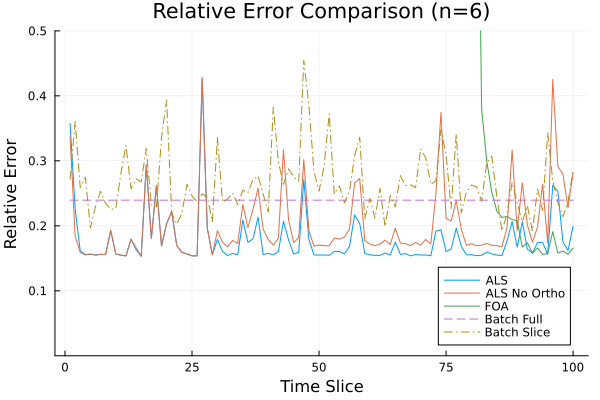

In [43]:
plot(1:T, relative_error_ALS, label="ALS")
plot!(1:T, relative_error_ALS_no_ortho, label="ALS No Ortho")
plot!(1:T, relative_error_FOA, label="FOA")
plot!(1:T, [relative_error_batch_full for _ in 1:T], label="Batch Full", linestyle=:dash)
plot!(1:T, relative_error_batchSlice, label="Batch Slice", linestyle=:dashdot)
xlabel!("Time Slice")
ylabel!("Relative Error")
ylims!(1e-10, 0.5)
title!("Relative Error Comparison (n=$(n))")

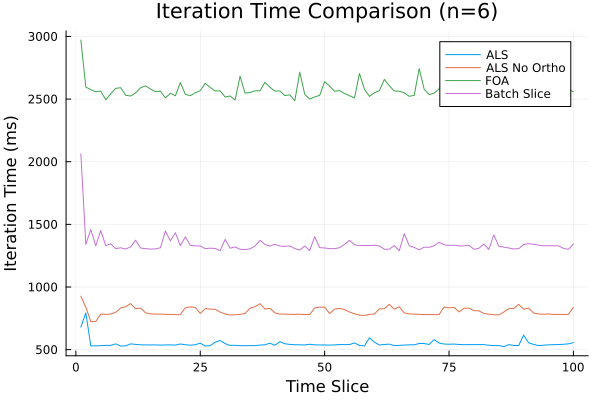

In [44]:
plot(1:T, iter_times_ALS, label="ALS")
plot!(1:T, iter_times_ALS_no_ortho, label="ALS No Ortho")
plot!(1:T, iter_times_FOA, label="FOA")
# plot!(1:T, [iter_time_batch for _ in 1:T], label="Batch Full")
plot!(1:T, iter_times_batchSlice, label="Batch Slice")
xlabel!("Time Slice")
ylabel!("Iteration Time (ms)")
title!("Iteration Time Comparison (n=$(n))")